In [1]:
import sys
import os

sys.path.append(os.path.join('..'))

In [2]:

%load_ext autoreload
%autoreload 2

In [3]:
BASE_DATA_DIR = os.path.join('..', 'data', 'metr-la', 'raw')

BASE_CONFIG_DIR = os.path.join('..', 'config', 'kepler', 'metr-la')

In [4]:
import pandas as pd
import tables

print("Pandas:", pd.__version__)
print("PyTables:", tables.__version__)
print("Tables location:", tables.__file__)

Pandas: 2.3.3
PyTables: 3.10.1
Tables location: c:\Users\admin\miniconda3\envs\traffic_new\lib\site-packages\tables\__init__.py


In [5]:
import pandas as pd
import os

file = os.path.join(BASE_DATA_DIR, "metr-la.h5")

store = pd.HDFStore(file)
print(store.keys())
store.close()

['/df']


In [6]:
df = pd.read_hdf(file, key="df")
print(df.shape)

(34272, 207)


In [7]:
from src.data.data_extraction import get_node_values_dataframe

node_values_df = get_node_values_dataframe(
    os.path.join(BASE_DATA_DIR, 'metr-la.h5'), turn_in_kmph=True)

In [8]:
node_values_df.head()

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,103.601520,108.831888,108.027216,98.974656,107.624880,110.642400,104.808528,108.027216,95.957136,100.986336,...,73.426320,105.412032,103.802688,106.906423,107.624880,95.5548,111.044736,95.353632,111.044736,99.578160
2012-03-01 00:05:00,100.852224,110.329472,105.322624,100.494592,103.713280,109.614208,104.607360,104.607360,92.447872,101.925120,...,81.540096,112.452912,107.289600,94.236032,99.779328,98.3488,103.713280,89.944448,110.150656,101.187504
2012-03-01 00:10:00,102.998016,102.595680,96.560640,94.951296,107.021376,106.619040,103.802688,103.400352,102.796848,105.210864,...,71.012304,111.044736,90.927936,95.353632,109.636560,100.5840,105.613200,98.773488,112.424174,99.779328
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000


In [9]:
print('Shape of the node value dataframe:', node_values_df.shape)

Shape of the node value dataframe: (34272, 207)


In [10]:
from src.data.data_extraction import get_locations_dataframe

locations_df = get_locations_dataframe(
    os.path.join(BASE_DATA_DIR, 'graph_sensor_locations.csv'),
    has_header=True)

In [11]:
locations_df.head()

,sensor_id,latitude,longitude
index,,,
0,773869,34.15497,-118.31829
1,767541,34.11621,-118.23799
2,767542,34.11641,-118.23819
3,717447,34.07248,-118.26772
4,717446,34.07142,-118.26572


In [12]:
print('Shape of the locations dataframe:', locations_df.shape)

Shape of the locations dataframe: (207, 3)


In [13]:
from src.data.data_analysis import show_kepler_map
print('Metr-LA spatial map:')
show_kepler_map(locations_df,
                os.path.join(BASE_CONFIG_DIR, 'spatial-map.json'))

c:\Users\admin\miniconda3\envs\traffic_new\lib\site-packages\keplergl\keplergl.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


Metr-LA spatial map:


KeplerGl(config={'version': 'v1', 'config': {'visState': {'layers': [{'id': 'msruhg9', 'type': 'point', 'confi…

In [15]:
from src.data.data_analysis import get_missing_values_by_location_dataframe

missing_values_by_location = get_missing_values_by_location_dataframe(
    node_values_df, locations_df)

d:\downloads_folder_chrome\sp_final_v3\notebooks\..\src\data\data_analysis.py:243: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: missing_values_per_node_ratio[x[0]], axis = 1


In [16]:
from src.data.data_analysis import show_kepler_map

print('Metr-LA percentage of total missing values per node:')
show_kepler_map(missing_values_by_location,
                os.path.join(BASE_CONFIG_DIR, 'missing-values-map.json'))

Metr-LA percentage of total missing values per node:


KeplerGl(config={'version': 'v1', 'config': {'visState': {'layers': [{'id': 'msruhg9', 'type': 'point', 'confi…

In [17]:
print('Total percentage of missing values:',
      f'{(node_values_df == 0.).to_numpy().mean() * 100:.2g} %')

Total percentage of missing values: 8.1 %


In [18]:
from src.data.data_analysis import get_day_dataframe

first_monday_df = get_day_dataframe(node_values_df, 'Monday')

In [19]:
from src.data.data_analysis import get_node_values_with_location_dataframe

location_df_with_speed = get_node_values_with_location_dataframe(
    first_monday_df, locations_df,
    metric_name='Speed', turn_datetimes_to_timestamp=False)

location_df_with_speed = location_df_with_speed[
    location_df_with_speed.Speed != 0]

d:\downloads_folder_chrome\sp_final_v3\notebooks\..\src\data\data_analysis.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  node_values_location_df = pd.concat(


In [20]:
from src.data.data_analysis import show_kepler_map

print('Metr-LA variation of node speed on the first Monday:')
show_kepler_map(location_df_with_speed,
                os.path.join(BASE_CONFIG_DIR, 'speed-on-first-monday.json'))

Metr-LA variation of node speed on the first Monday:


KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [{'dataId': ['data'], 'id': 'se0vr0gv', '…

In [21]:
from src.data.data_analysis import show_kepler_map

print('Metr-LA speed clusters on the first Monday:')
show_kepler_map(location_df_with_speed,
                os.path.join(BASE_CONFIG_DIR, 'clusters-on-first-monday.json'))

Metr-LA speed clusters on the first Monday:


KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [{'dataId': ['data'], 'id': 'se0vr0gv', '…

In [23]:
from src.data.data_analysis import (
    get_node_values_df_of_nodes_with_largest_speed_variation)

node_values_reduced = get_node_values_df_of_nodes_with_largest_speed_variation(
    node_values_df)

In [24]:
node_values_reduced.head()

,717458,716339,717462
2012-03-01 00:00:00,103.199184,103.400352,111.648240
2012-03-01 00:05:00,102.819200,106.931968,111.581184
2012-03-01 00:10:00,104.607360,104.205024,111.849408
2012-03-01 00:15:00,0.000000,0.000000,0.000000
2012-03-01 00:20:00,0.000000,0.000000,0.000000


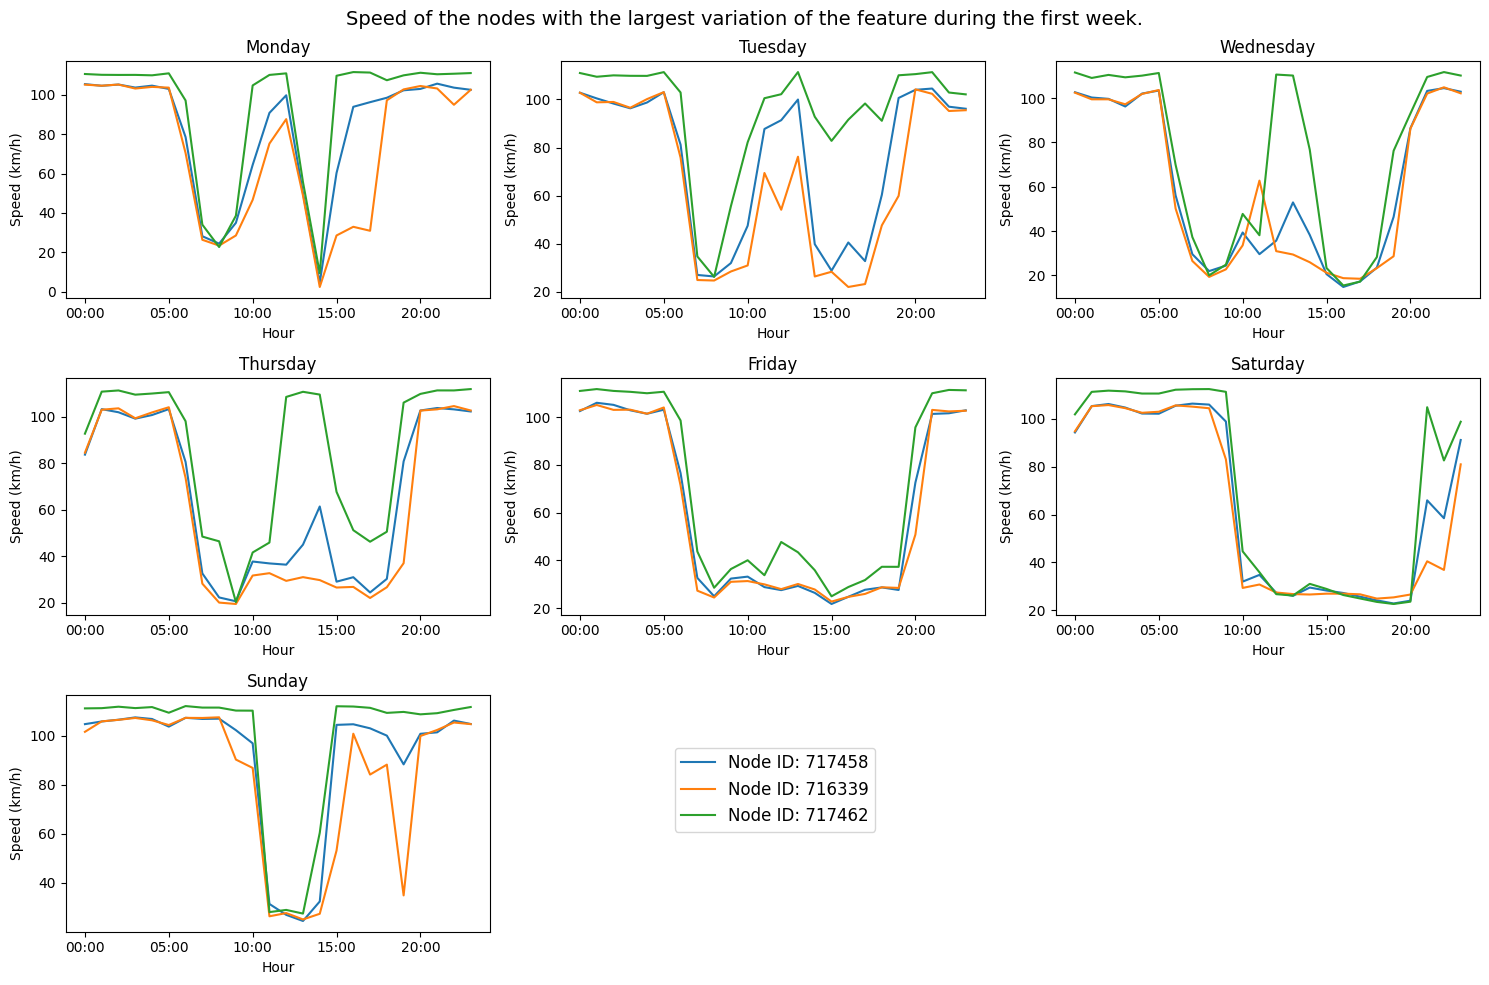

In [25]:
from src.data.data_analysis import plot_daily_speed_variation

plot_daily_speed_variation(node_values_reduced)

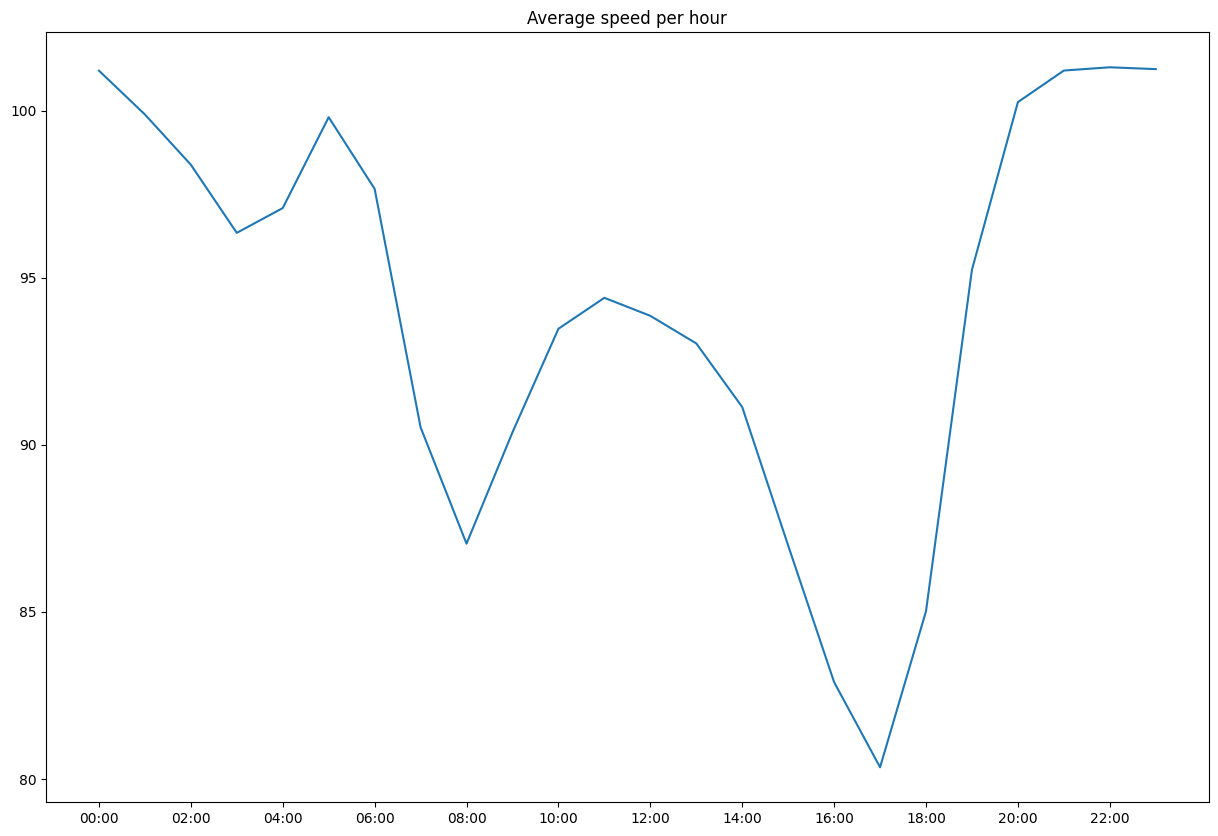

In [26]:
from src.data.data_analysis import plot_average_speed_by_hour

plot_average_speed_by_hour(node_values_df)

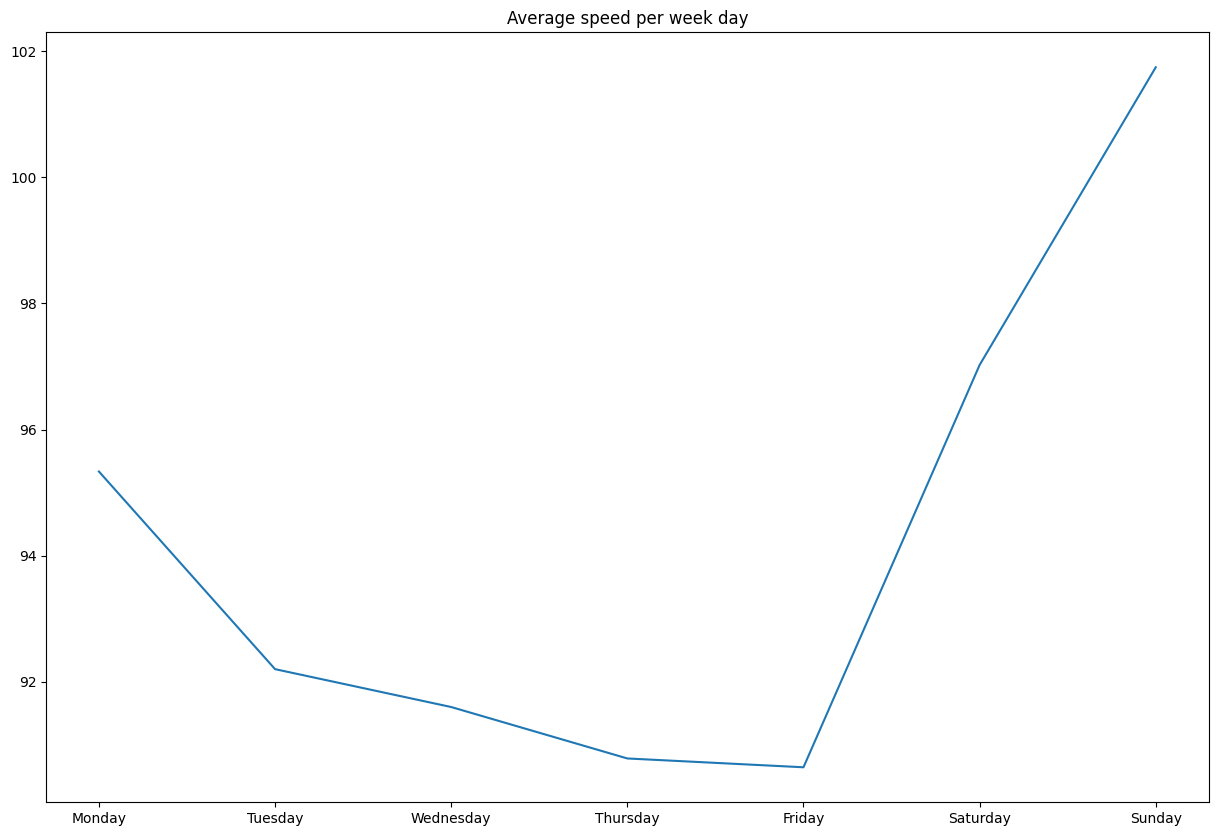

In [27]:
from src.data.data_analysis import plot_average_speed_by_day

plot_average_speed_by_day(node_values_df)

In [28]:
from src.data.data_processing import get_node_values_numpy_matrix

node_values_np, _ = get_node_values_numpy_matrix(
    node_values_df,
    time_aggregations=['time_of_day', 'day_of_week'])

In [29]:
from src.data.data_analysis import get_node_values_statistics_dataframe

statistics_df = get_node_values_statistics_dataframe(
    node_values_np, feature_names=['speed', 'time of day', 'day of week'],
    has_day_of_the_week=True)

d:\downloads_folder_chrome\sp_final_v3\notebooks\..\src\data\data_analysis.py:203: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[ax].set_xticklabels([f'{int(t):02d}:00' for t in range(-5, 25, 5)])


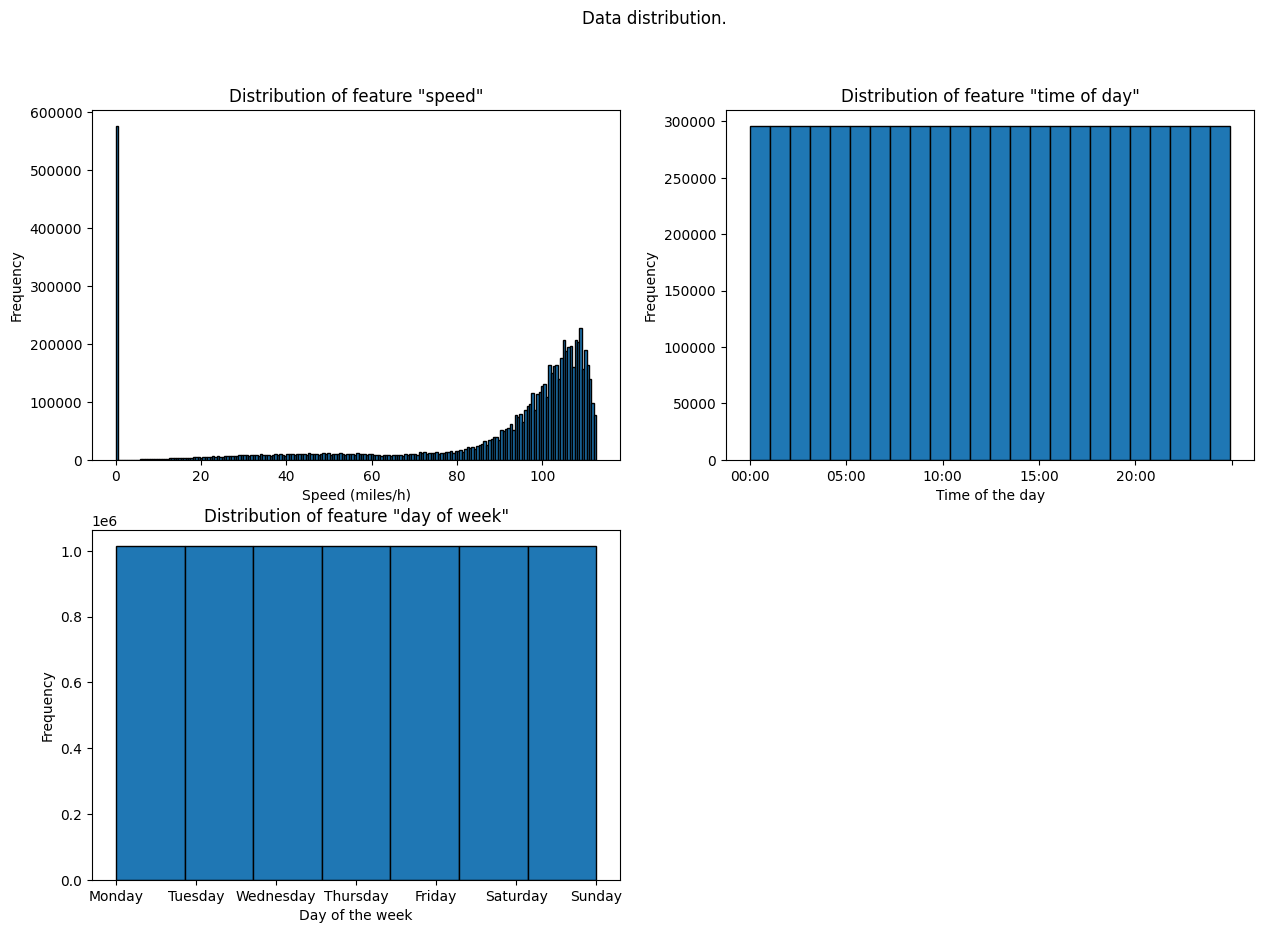

In [30]:
from src.data.data_analysis import plot_data_distribution

plot_data_distribution(
    statistics_df, bins=[200, 24, 7], 
    x_labels=['Speed (miles/h)', 'Time of the day',
              'Day of the week'],
    title='Data distribution.')